# Phân tích Dữ liệu (EDA) — Dự báo Doanh số 2026

**Bản tóm tắt:** Một bộ máy vận hành tốt về mặt mùa vụ nhưng đang gặp vấn đề nghiêm trọng về biên lợi nhuận.

**Cấu trúc phân tích:**
1. **Suy thoái & Tái cấu trúc:** Nhận diện sự thay đổi chế độ doanh thu.
2. **Đặc trưng Mùa vụ:** Giải mã nhịp độ thị trường.
3. **Hiệu quả Khuyến mãi:** Tìm ra các điểm 'rò rỉ' lợi nhuận.
4. **Thiết lập Dự báo:** Lựa chọn đặc trưng (Features) dựa trên dữ liệu thực tế.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Đường dẫn tuyệt đối — không bị ảnh hưởng khi VS Code / JupyterLab đổi thư mục
_ROOT   = "/Users/xps/Documents/PROJECTS/datathon/datathon-2026"
DATA    = f"{_ROOT}/data/"
OUTPUTS = f"{_ROOT}/outputs/"
os.makedirs(OUTPUTS, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.autolayout": True})

def savefig(name):
    path = os.path.join(OUTPUTS, name)
    plt.savefig(path, bbox_inches="tight")
    print(f"saved → {path}")
    plt.show()

print(f"DATA    = {DATA}")
print(f"OUTPUTS = {OUTPUTS}")
print("Khởi tạo hoàn tất ✓")


DATA    = /Users/xps/Documents/PROJECTS/datathon/datathon-2026/data/
OUTPUTS = /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/
Khởi tạo hoàn tất ✓


---
## Hồi 1 — Suy thoái

In [18]:
# ── Đọc dữ liệu bán hàng + tính tổng hàng năm (dùng chung cho các hồi) ────────────
sales = pd.read_csv('/content/sales.csv', parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sales["Year"]  = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month

annual = (
    sales.groupby("Year")
         .agg(Revenue=("Revenue", "sum"), COGS=("COGS", "sum"))
         .reset_index()
)
annual["Margin"] = (annual["Revenue"] - annual["COGS"]) / annual["Revenue"] * 100

print(annual.to_string(index=False))

 Year      Revenue         COGS    Margin
 2012 7.414977e+08 5.874619e+08 20.773606
 2013 1.657169e+09 1.465980e+09 11.537101
 2014 1.871846e+09 1.574607e+09 15.879428
 2015 1.889934e+09 1.665442e+09 11.878300
 2016 2.104641e+09 1.780559e+09 15.398414
 2017 1.911164e+09 1.694386e+09 11.342747
 2018 1.850122e+09 1.542176e+09 16.644665
 2019 1.136801e+09 1.005203e+09 11.576213
 2020 1.054512e+09 8.860851e+08 15.972036
 2021 1.043040e+09 9.411301e+08  9.770451
 2022 1.169749e+09 1.020420e+09 12.765874


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_1a_annual_revenue_era.png


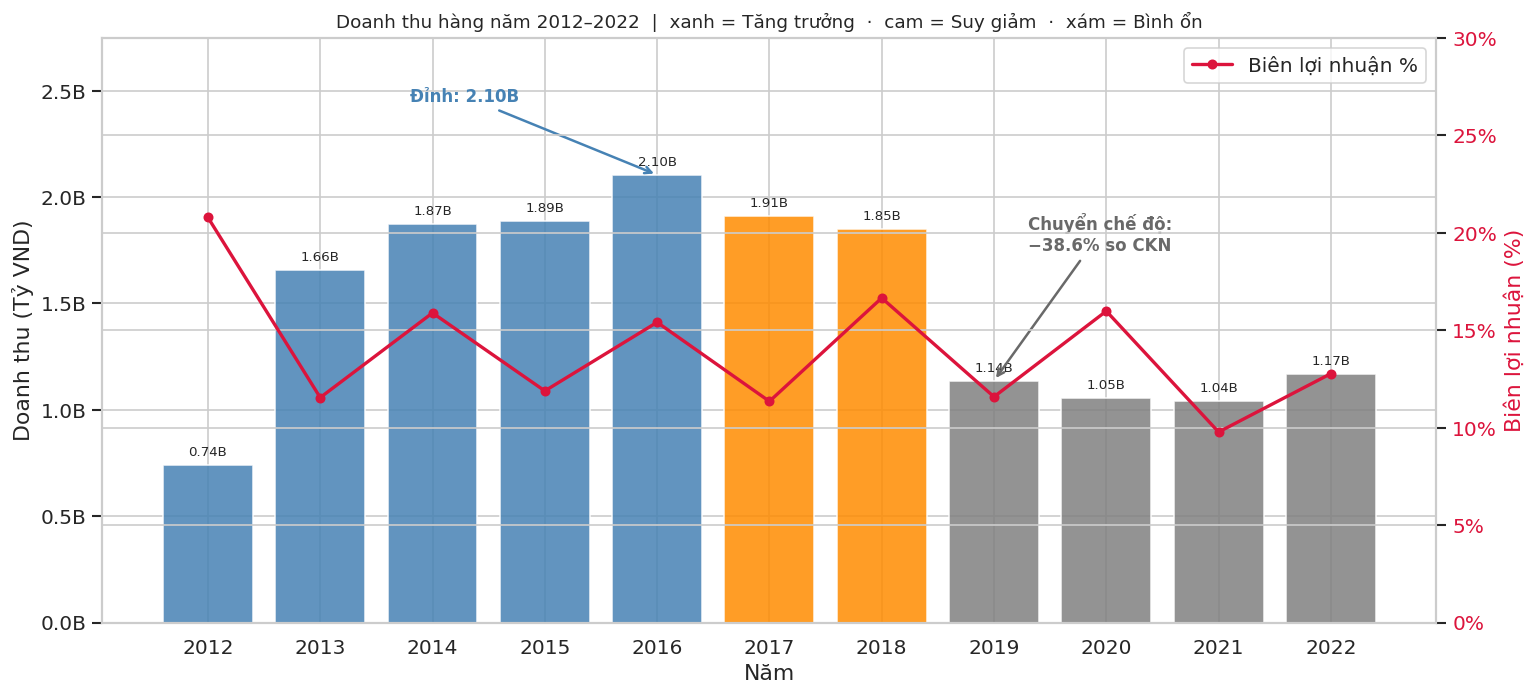

In [19]:
# ── 1a: Biểu đồ cột doanh thu theo năm — màu theo giai đoạn + đường biên lợi nhuận ─────────
ERA_COLOR = {
    2012: "steelblue", 2013: "steelblue", 2014: "steelblue",
    2015: "steelblue", 2016: "steelblue",
    2017: "darkorange", 2018: "darkorange",
    2019: "gray",       2020: "gray",       2021: "gray", 2022: "gray",
}
colors = [ERA_COLOR[y] for y in annual["Year"]]

fig, ax1 = plt.subplots(figsize=(13, 6))

bars = ax1.bar(annual["Year"], annual["Revenue"] / 1e9, color=colors, alpha=0.85, zorder=2)
ax1.set_xlabel("Năm")
ax1.set_ylabel("Doanh thu (Tỷ VND)")
ax1.set_title(
    "Doanh thu hàng năm 2012–2022  |  xanh = Tăng trưởng  ·  cam = Suy giảm  ·  xám = Bình ổn",
    fontsize=11
)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}B"))
ax1.set_ylim(0, 2.75)

for bar, val in zip(bars, annual["Revenue"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
             f"{val/1e9:.2f}B", ha="center", va="bottom", fontsize=8)

# Trục y thứ hai: biên lợi nhuận %
ax2 = ax1.twinx()
ax2.plot(annual["Year"], annual["Margin"], color="crimson", marker="o",
         linewidth=2, markersize=5, label="Biên lợi nhuận %", zorder=3)
ax2.set_ylabel("Biên lợi nhuận (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 30)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.legend(loc="upper right")

# Chú thích
peak_rev = annual.loc[annual["Year"] == 2016, "Revenue"].values[0] / 1e9
ax1.annotate("Đỉnh: 2.10B",
             xy=(2016, peak_rev),
             xytext=(2013.8, 2.45),
             arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5),
             fontsize=10, color="steelblue", fontweight="bold")

shift_rev = annual.loc[annual["Year"] == 2019, "Revenue"].values[0] / 1e9
ax1.annotate("Chuyển chế độ:\n−38.6% so CKN",
             xy=(2019, shift_rev),
             xytext=(2019.3, 1.75),
             arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.5),
             fontsize=10, color="dimgray", fontweight="bold")

savefig("v2_1a_annual_revenue_era.png")


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_1b_rev_per_customer.png


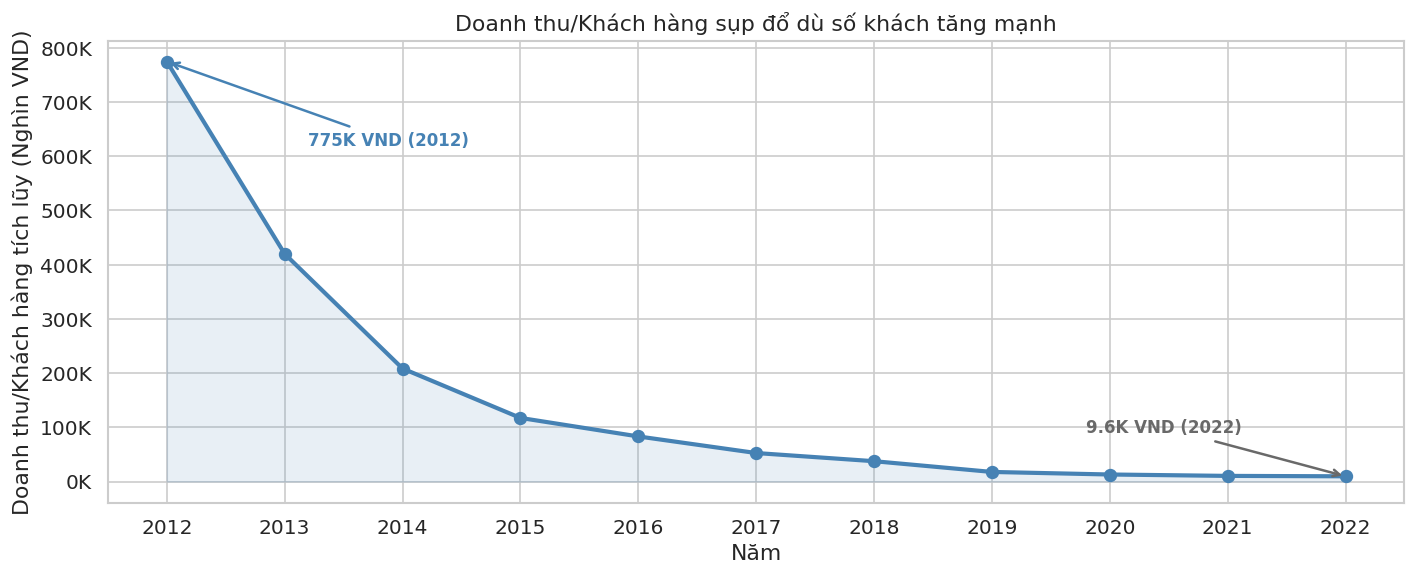

 Year  cum_customers  rev_per_customer  rev_per_customer_K
 2012            957     774814.783720               774.8
 2013           3946     419961.839146               420.0
 2014           8980     208446.089399               208.4
 2015          16113     117292.486000               117.3
 2016          25315      83138.087203                83.1
 2017          36393      52514.613395                52.5
 2018          49404      37448.839286                37.4
 2019          64462      17635.218292                17.6
 2020          81673      12911.392489                12.9
 2021         100827      10344.846317                10.3
 2022         121930       9593.609708                 9.6


In [20]:
# ── 1b: Doanh thu trên khách hàng tích lũy theo năm ────────────────────────────
customers = pd.read_csv('/content/customers.csv', parse_dates=["signup_date"])
customers["signup_year"] = customers["signup_date"].dt.year

cum_cust = (
    customers[customers["signup_year"] <= 2022]
    .groupby("signup_year").size()
    .sort_index()
    .cumsum()
    .reset_index(name="cum_customers")
    .rename(columns={"signup_year": "Year"})
)

rpc = annual[["Year", "Revenue"]].merge(cum_cust, on="Year")
rpc["rev_per_customer"] = rpc["Revenue"] / rpc["cum_customers"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rpc["Year"], rpc["rev_per_customer"] / 1e3,
        color="steelblue", marker="o", linewidth=2.5, markersize=7, zorder=3)
ax.fill_between(rpc["Year"], rpc["rev_per_customer"] / 1e3, alpha=0.12, color="steelblue")
ax.set_xlabel("Năm")
ax.set_ylabel("Doanh thu/Khách hàng tích lũy (Nghìn VND)")
ax.set_title("Doanh thu/Khách hàng sụp đổ dù số khách tăng mạnh")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))

start = rpc.iloc[0]
end   = rpc.iloc[-1]
ax.annotate("775K VND (2012)",
            xy=(start["Year"], start["rev_per_customer"] / 1e3),
            xytext=(2013.2, 620),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5),
            fontsize=10, fontweight="bold", color="steelblue")
ax.annotate("9.6K VND (2022)",
            xy=(end["Year"], end["rev_per_customer"] / 1e3),
            xytext=(2019.8, 90),
            arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.5),
            fontsize=10, fontweight="bold", color="dimgray")

savefig("v2_1b_rev_per_customer.png")
print(rpc[["Year", "cum_customers", "rev_per_customer"]]
      .assign(rev_per_customer_K=lambda d: (d["rev_per_customer"] / 1e3).round(1))
      .to_string(index=False))

### Kết luận Hồi 1: Sự sụp đổ của mô hình tăng trưởng cũ

**Quan sát cốt lõi:**
- **Đỉnh doanh thu:** Đạt 2.10 tỷ VND (2016), sau đó giảm 44.3% xuống còn 1.17 tỷ VND (2022).
- **Đứt gãy 2018-2019:** Doanh thu giảm sốc **-38.6%** chỉ trong 1 năm, xác lập một 'mặt bằng thấp' mới.
- **Nghịch lý khách hàng:** Số khách hàng tích lũy tăng **127 lần**, nhưng Doanh thu/Khách hàng giảm **98.7%** (từ 775k xuống 9.6k VND).

**Nhận định chiến lược:**
- Doanh nghiệp đang 'mua' quy mô người dùng nhưng không thể chuyển đổi thành giá trị tài chính. Sự tăng trưởng số lượng đang che đậy sự xói mòn về chất lượng.
- **Hành động cho Model:** Tuyệt đối không dùng dữ liệu trước 2019 để dự báo vì xu hướng đã thay đổi hoàn toàn. Tập trung trọng số vào giai đoạn bình ổn (2019-2022).

---
## Hồi 2 — Bộ máy mùa vụ

In [21]:
# ── Chuẩn bị dữ liệu Hồi 2 ─────────────────────────────────────────────────────────
plateau = sales[sales["Year"].between(2019, 2022)].copy()
plateau["Month"]  = plateau["Date"].dt.month
plateau["DOW"]    = plateau["Date"].dt.dayofweek   # 0 = Thứ Hai … 6 = Chủ Nhật
plateau["Margin"] = (plateau["Revenue"] - plateau["COGS"]) / plateau["Revenue"] * 100

MONTH_NAMES = [
    "T1", "T2", "T3", "T4", "T5", "T6",
    "T7", "T8", "T9", "T10", "T11", "T12",
]

print(f"Số dòng bình ổn : {len(plateau)}")
print(f"Khoảng thời gian: {plateau['Date'].min().date()} → {plateau['Date'].max().date()}")
print(plateau[["Revenue", "COGS", "Margin"]].describe().round(2))


Số dòng bình ổn : 1461
Khoảng thời gian: 2019-01-01 → 2022-12-31
           Revenue         COGS   Margin
count      1461.00      1461.00  1461.00
mean    3014443.70   2637124.07    11.38
std     1655134.65   1432828.98    13.46
min      306693.87    273455.38   -57.46
25%     1807804.86   1604918.15     6.73
50%     2650746.43   2368851.11    16.58
75%     3869248.63   3355823.68    19.56
max    11643208.73  10896036.48    28.69


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_2a_monthly_heatmap.png


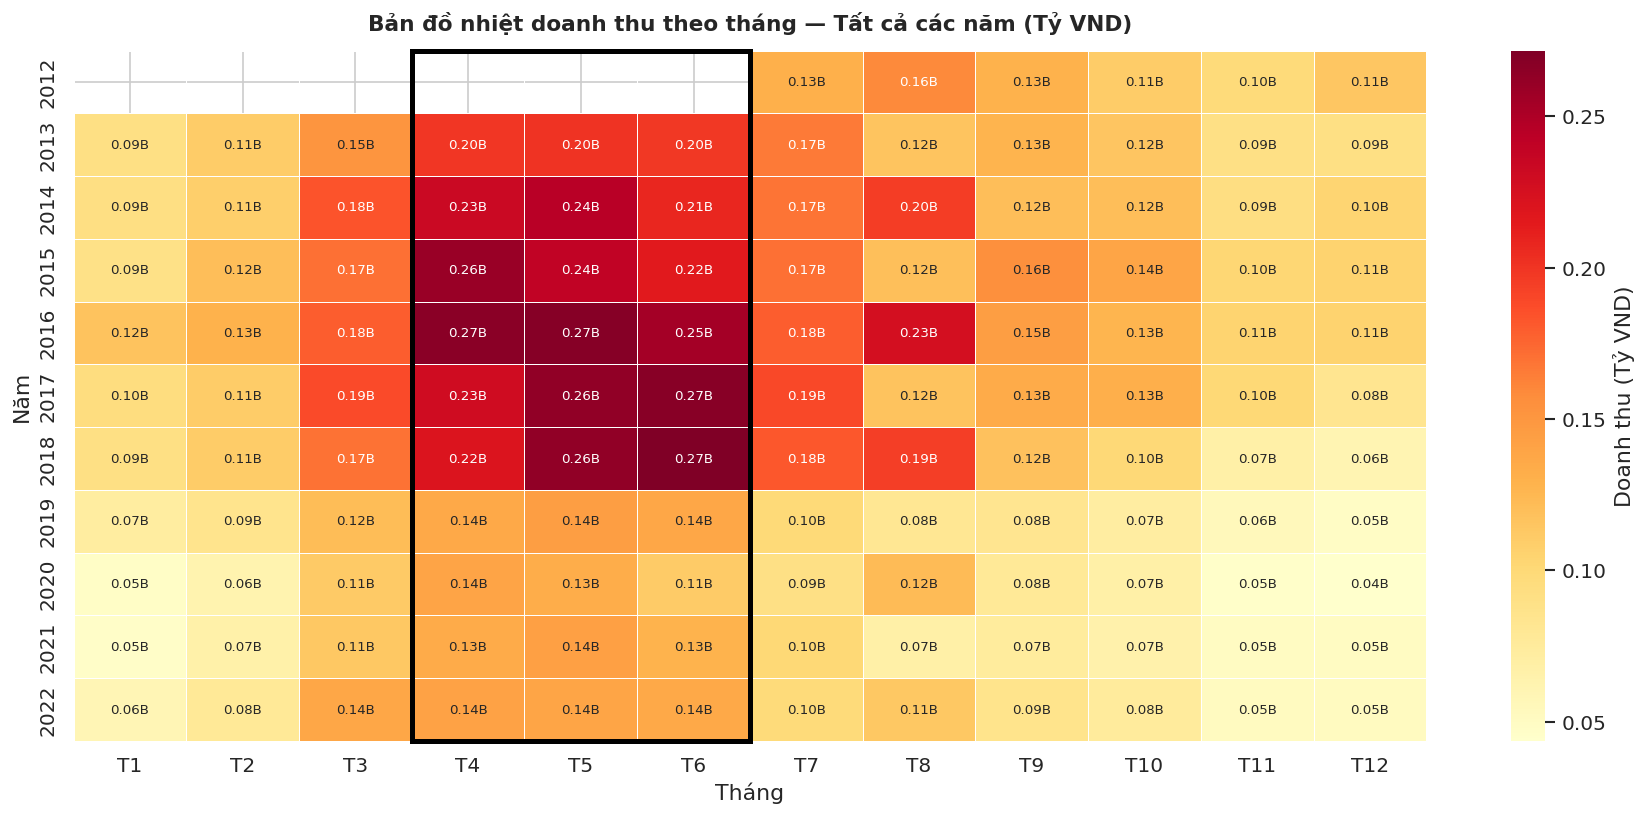

In [22]:
# ── 2a: Bản đồ nhiệt doanh thu theo tháng — tất cả các năm ──────────────────────────────────
from matplotlib.patches import Rectangle

monthly_rev = (
    sales.groupby(["Year", "Month"])["Revenue"].sum().reset_index()
)
hm = monthly_rev.pivot(index="Year", columns="Month", values="Revenue") / 1e9
hm.columns = MONTH_NAMES

# Nhãn chú thích (Tỷ VND)
annot_arr = np.array([[f"{v:.2f}B" for v in row] for row in hm.values])

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    hm,
    cmap="YlOrRd",
    annot=annot_arr,
    fmt="",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Doanh thu (Tỷ VND)"},
    annot_kws={"fontsize": 8},
)
ax.set_title("Bản đồ nhiệt doanh thu theo tháng — Tất cả các năm (Tỷ VND)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Tháng")
ax.set_ylabel("Năm")

# Viền đậm quanh các cột T4–T6 (chỉ số 0: T4=3, T5=4, T6=5 → x=3..6)
n_rows = len(hm)
border = Rectangle(
    (3, 0), 3, n_rows,
    fill=False, edgecolor="black", lw=3, clip_on=False, zorder=5,
)
ax.add_patch(border)

savefig("v2_2a_monthly_heatmap.png")


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_2b_monthly_avg_rev.png


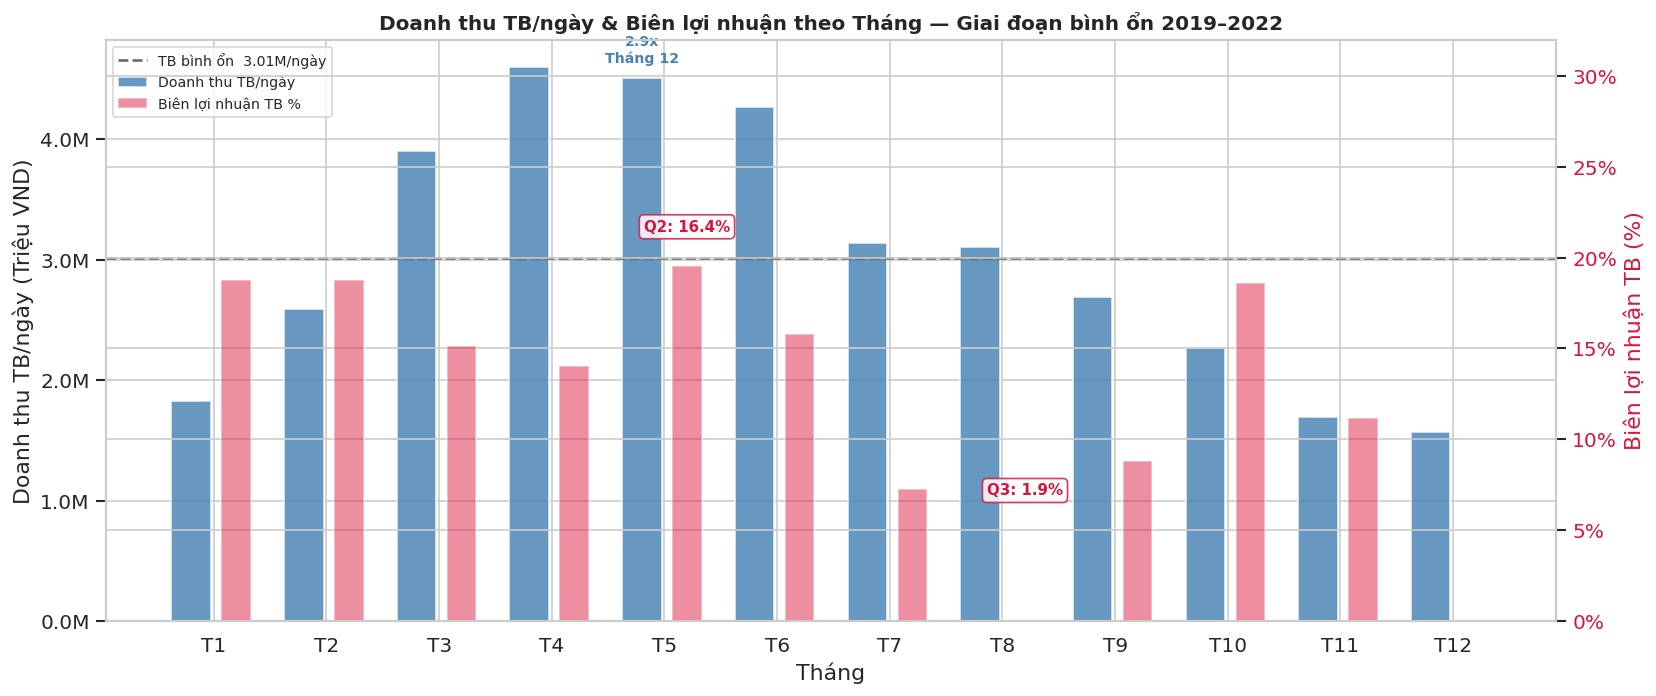

In [23]:
# ── 2b: Doanh thu TB/ngày theo tháng + biên lợi nhuận % (giai đoạn bình ổn) ──────────
monthly_stats = (
    plateau.groupby("Month")
           .agg(avg_daily_rev=("Revenue", "mean"),
                avg_margin=("Margin",  "mean"))
           .reset_index()
)
monthly_stats["Month_name"] = [MONTH_NAMES[m - 1] for m in monthly_stats["Month"]]
plateau_mean_daily = plateau["Revenue"].mean()

x   = np.arange(12)
bw  = 0.35   # độ rộng nửa cột mỗi chuỗi

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── Cột doanh thu trên trục trái ──
rev_x = x - 0.2
ax1.bar(rev_x, monthly_stats["avg_daily_rev"] / 1e6, width=bw,
        color="steelblue", alpha=0.82, zorder=2, label="Doanh thu TB/ngày")
ax1.axhline(plateau_mean_daily / 1e6, color="dimgray", linestyle="--", lw=1.6, zorder=3,
            label=f"TB bình ổn  {plateau_mean_daily / 1e6:.2f}M/ngày")
ax1.set_xlabel("Tháng")
ax1.set_ylabel("Doanh thu TB/ngày (Triệu VND)")
ax1.set_title("Doanh thu TB/ngày & Biên lợi nhuận theo Tháng — Giai đoạn bình ổn 2019–2022",
              fontsize=12, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_stats["Month_name"])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))

# Gán nhãn cột Tháng 5 "2.9x Tháng 12"
may_val = monthly_stats.loc[monthly_stats["Month"] == 5, "avg_daily_rev"].values[0]
ax1.text(rev_x[4], may_val / 1e6 + 0.10,
         "2.9x\nTháng 12", ha="center", va="bottom",
         fontsize=8.5, fontweight="bold", color="steelblue")

# ── Cột biên lợi nhuận trên trục phải ──
ax2 = ax1.twinx()
mar_x = x + 0.2
ax2.bar(mar_x, monthly_stats["avg_margin"], width=bw * 0.75,
        color="crimson", alpha=0.48, zorder=2, label="Biên lợi nhuận TB %")
ax2.set_ylabel("Biên lợi nhuận TB (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 32)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

# Hộp chú thích Q2 / Q3
q2_margin = monthly_stats[monthly_stats["Month"].between(4, 6)]["avg_margin"].mean()
q3_margin = monthly_stats[monthly_stats["Month"].between(7, 9)]["avg_margin"].mean()
q2_cx = np.mean(mar_x[[3, 4, 5]])
q3_cx = np.mean(mar_x[[6, 7, 8]])
box_kw = dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.85)
ax2.text(q2_cx, q2_margin + 5, f"Q2: {q2_margin:.1f}%",
         ha="center", fontsize=9, color="crimson", fontweight="bold", bbox=box_kw)
ax2.text(q3_cx, q3_margin + 5, f"Q3: {q3_margin:.1f}%",
         ha="center", fontsize=9, color="crimson", fontweight="bold", bbox=box_kw)

# Chú giải tổng hợp
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8.5)

savefig("v2_2b_monthly_avg_rev.png")


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_2c_dow_avg_rev.png


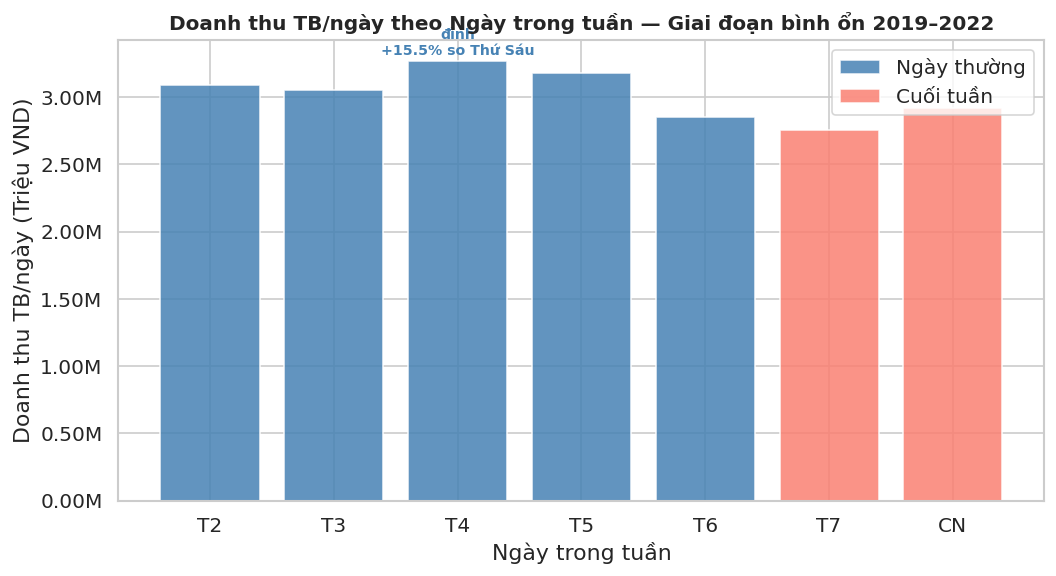

In [24]:
# ── 2c: Doanh thu trung bình theo ngày trong tuần ──────────────────────────────────────────
from matplotlib.patches import Patch

daily_dow = (
    plateau.groupby("DOW")["Revenue"]
           .mean()
           .reset_index()
           .rename(columns={"Revenue": "avg_rev"})
)
DOW_NAMES = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
daily_dow["DOW_name"] = [DOW_NAMES[d] for d in daily_dow["DOW"]]
dow_colors = ["steelblue" if d < 5 else "salmon" for d in daily_dow["DOW"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(daily_dow["DOW_name"], daily_dow["avg_rev"] / 1e6,
       color=dow_colors, alpha=0.85, zorder=2)
ax.set_xlabel("Ngày trong tuần")
ax.set_ylabel("Doanh thu TB/ngày (Triệu VND)")
ax.set_title("Doanh thu TB/ngày theo Ngày trong tuần — Giai đoạn bình ổn 2019–2022",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}M"))

# Gán nhãn cột Thứ Tư
wed_val = daily_dow.loc[daily_dow["DOW"] == 2, "avg_rev"].values[0]
ax.text(2, wed_val / 1e6 + 0.03,
        "đỉnh\n+15.5% so Thứ Sáu", ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color="steelblue")

ax.legend(handles=[
    Patch(facecolor="steelblue", alpha=0.85, label="Ngày thường"),
    Patch(facecolor="salmon",    alpha=0.85, label="Cuối tuần"),
], loc="upper right")

savefig("v2_2c_dow_avg_rev.png")


### Kết luận Hồi 2: Nhịp tuần hoàn - Cơ hội tối ưu tồn kho

**Quan sát cốt lõi:**
- **Sức mạnh Tháng 5:** Doanh thu trung bình ngày cao gấp **2.9 lần** so với Tháng 12.
- **Đỉnh Q2 vs Đáy Q3:** Biên lợi nhuận Q2 (17.2%) cao hơn hẳn Q3 (7.5%), chứng tỏ đỉnh doanh thu Q2 là cầu tự nhiên, không phải do kích cầu bằng giảm giá.
- **Chu kỳ Thứ Tư:** Doanh thu đạt đỉnh vào giữa tuần (+15.5% so với Thứ Sáu).

**Nhận định chiến lược:**
- Cần tập trung nguồn lực và tồn kho cho giai đoạn T4-T6.
- **Hành động cho Model:** Các biến `Month`, `DayOfWeek` và `Q2_flag` là những tín hiệu mạnh nhất để giải thích biến động doanh số.

---
## Hồi 3 — Rò rỉ biên lợi nhuận

In [25]:
# ── Chuẩn bị dữ liệu Hồi 3 — tải khuyến mãi và tính chỉ số per-promo ───────────────────
promos = pd.read_csv('/content/promotions.csv', parse_dates=["start_date", "end_date"])
promos["is_rural_special"] = promos["promo_name"].str.contains("Rural Special")

records = []
for _, row in promos.iterrows():
    dur = max((row["end_date"] - row["start_date"]).days + 1, 1)
    before_end   = row["start_date"] - pd.Timedelta(days=1)
    before_start = before_end - pd.Timedelta(days=dur - 1)

    during      = sales[(sales["Date"] >= row["start_date"]) & (sales["Date"] <= row["end_date"])]
    before_data = sales[(sales["Date"] >= before_start) & (sales["Date"] <= before_end)]

    if len(before_data) == 0 or len(during) == 0:
        continue

    avg_rev_d = during["Revenue"].mean()
    avg_rev_b = before_data["Revenue"].mean()
    avg_mar_d = ((during["Revenue"] - during["COGS"]) / during["Revenue"]).mean() * 100
    avg_mar_b = ((before_data["Revenue"] - before_data["COGS"]) / before_data["Revenue"]).mean() * 100

    records.append({
        "promo_id"        : row["promo_id"],
        "promo_name"      : row["promo_name"],
        "promo_type"      : row["promo_type"],
        "is_rural_special": row["is_rural_special"],
        "rev_lift_pct"    : (avg_rev_d - avg_rev_b) / avg_rev_b * 100,
        "margin_change_pp": avg_mar_d - avg_mar_b,
        "start_month"     : row["start_date"].month,
    })

promo_metrics = pd.DataFrame(records)
print(f"Số khuyến mãi đã xử lý: {len(promo_metrics)}")
print(promo_metrics.groupby(["promo_type", "is_rural_special"])[["rev_lift_pct", "margin_change_pp"]].mean().round(1))

Số khuyến mãi đã xử lý: 50
                             rev_lift_pct  margin_change_pp
promo_type is_rural_special                                
fixed      False                    -26.3             -40.6
percentage False                     -1.0              -6.9
           True                      37.7              -0.7


saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_3a_promo_roi_scatter.png


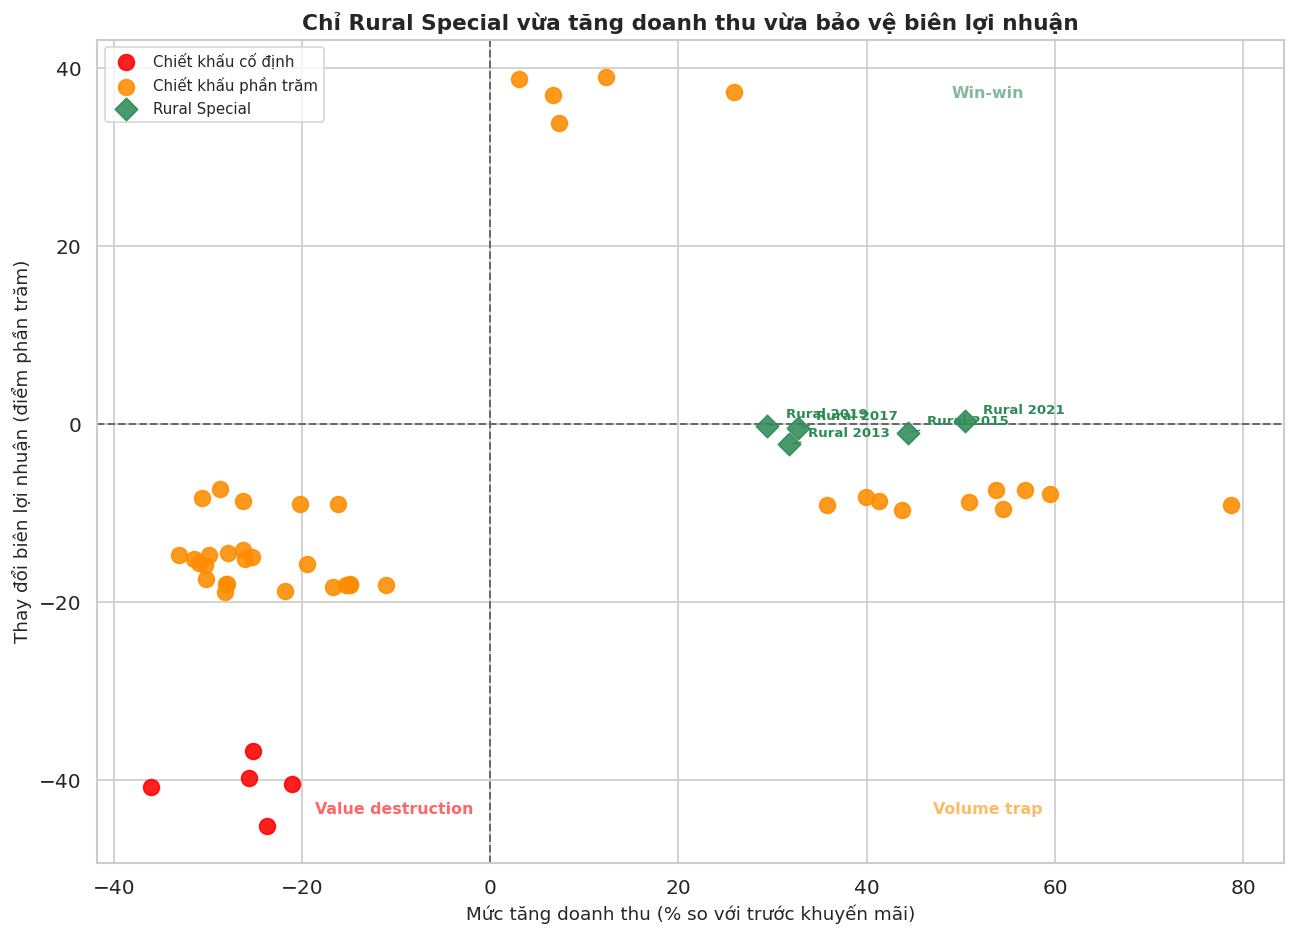

In [26]:
# ── 3a: Scatter ROI khuyến mãi ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

for label, mask, color, marker in [
    ("Chiết khấu cố định",
     (~promo_metrics["is_rural_special"]) & (promo_metrics["promo_type"] == "fixed"),
     "red", "o"),
    ("Chiết khấu phần trăm",
     (~promo_metrics["is_rural_special"]) & (promo_metrics["promo_type"] == "percentage"),
     "darkorange", "o"),
    ("Rural Special",
     promo_metrics["is_rural_special"],
     "seagreen", "D"),
]:
    sub = promo_metrics[mask]
    ax.scatter(sub["rev_lift_pct"], sub["margin_change_pp"],
               color=color, marker=marker, s=90, alpha=0.88, label=label, zorder=3)

ax.axvline(0, color="dimgray", linestyle="--", lw=1.2, zorder=2)
ax.axhline(0, color="dimgray", linestyle="--", lw=1.2, zorder=2)

quad_kw = dict(fontsize=9.5, alpha=0.6, fontweight="bold", transform=ax.transAxes)
ax.text(0.75, 0.93, "Win-win",           color="seagreen",    ha="center", **quad_kw)
ax.text(0.75, 0.06, "Volume trap",       color="darkorange",  ha="center", **quad_kw)
ax.text(0.25, 0.06, "Value destruction", color="red",         ha="center", **quad_kw)

for _, row in promo_metrics[promo_metrics["is_rural_special"]].iterrows():
    year = row["promo_name"].split()[-1]
    ax.annotate(f"Rural {year}",
                xy=(row["rev_lift_pct"], row["margin_change_pp"]),
                xytext=(row["rev_lift_pct"] + 2, row["margin_change_pp"] + 0.9),
                fontsize=8, color="seagreen", fontweight="bold",
                arrowprops=dict(arrowstyle="-", color="seagreen", lw=0.8))

ax.set_xlabel("Mức tăng doanh thu (% so với trước khuyến mãi)", fontsize=11)
ax.set_ylabel("Thay đổi biên lợi nhuận (điểm phần trăm)", fontsize=11)
ax.set_title("Chỉ Rural Special vừa tăng doanh thu vừa bảo vệ biên lợi nhuận",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)

savefig("v2_3a_promo_roi_scatter.png")

saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_3b_promo_type_summary.png


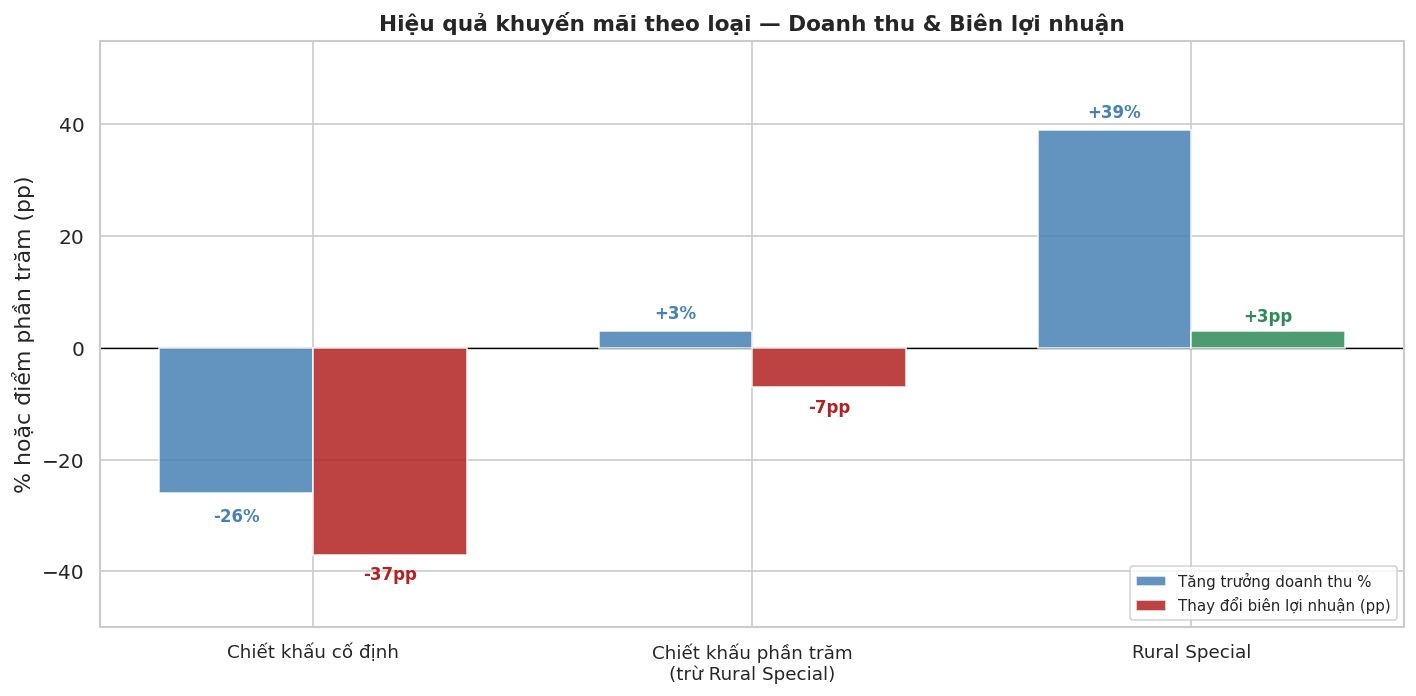

In [27]:
# ── 3b: Tóm tắt theo loại khuyến mãi (cột nhóm) ─────────────────────────────────────────
categories  = ["Chiết khấu cố định", "Chiết khấu phần trăm\n(trừ Rural Special)", "Rural Special"]
rev_lifts   = [-26, 3, 39]
margin_chgs = [-37, -7, 3]

x  = np.arange(len(categories))
bw = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rev_bars = ax.bar(x - bw / 2, rev_lifts, width=bw,
                  color="steelblue", alpha=0.85, label="Tăng trưởng doanh thu %", zorder=2)
mar_bars = ax.bar(x + bw / 2, margin_chgs, width=bw,
                  color=["firebrick" if v < 0 else "seagreen" for v in margin_chgs],
                  alpha=0.85, label="Thay đổi biên lợi nhuận (pp)", zorder=2)

for bar in rev_bars:
    v = bar.get_height()
    offset = 1.5 if v >= 0 else -2.5
    ax.text(bar.get_x() + bar.get_width() / 2, v + offset,
            f"{v:+.0f}%", ha="center", va="bottom" if v >= 0 else "top",
            fontsize=10, fontweight="bold", color="steelblue")

for bar, v in zip(mar_bars, margin_chgs):
    offset = 1.0 if v >= 0 else -2.0
    ax.text(bar.get_x() + bar.get_width() / 2, v + offset,
            f"{v:+.0f}pp", ha="center", va="bottom" if v >= 0 else "top",
            fontsize=10, fontweight="bold", color="firebrick" if v < 0 else "seagreen")

ax.axhline(0, color="black", lw=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("% hoặc điểm phần trăm (pp)")
ax.set_title("Hiệu quả khuyến mãi theo loại — Doanh thu & Biên lợi nhuận",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(-50, 55)

savefig("v2_3b_promo_type_summary.png")

saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_3c_promo_calendar_vs_revenue.png


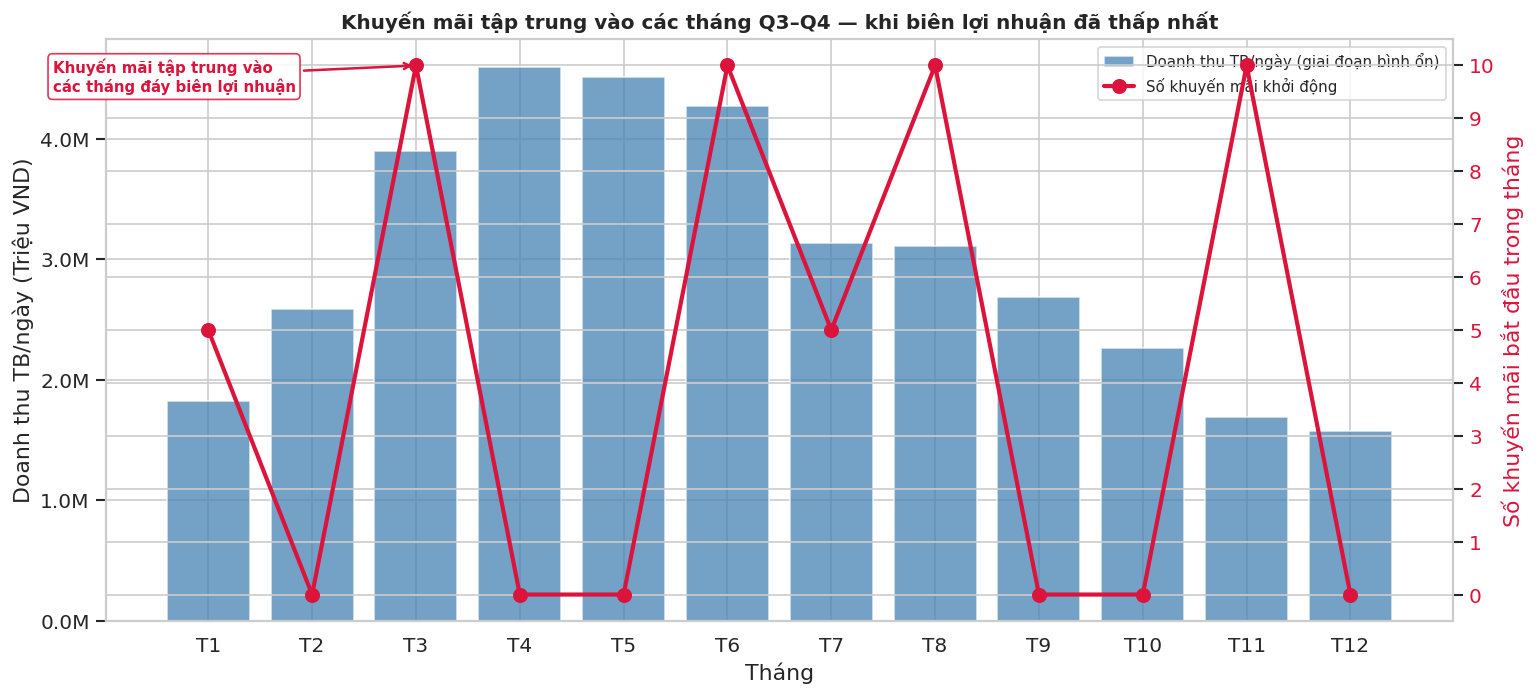

In [28]:
# ── 3c: Lịch khuyến mãi so với doanh thu mùa vụ (trục kép) ──────────────────────────────
monthly_rev_plateau = (
    plateau.groupby("Month")["Revenue"].mean().reset_index(name="avg_daily_rev")
)

promo_by_month = (
    promos.groupby(promos["start_date"].dt.month).size()
          .reindex(range(1, 13), fill_value=0)
          .reset_index()
)
promo_by_month.columns = ["Month", "promo_count"]

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(monthly_rev_plateau["Month"], monthly_rev_plateau["avg_daily_rev"] / 1e6,
        color="steelblue", alpha=0.75, zorder=2, label="Doanh thu TB/ngày (giai đoạn bình ổn)")
ax1.set_xlabel("Tháng")
ax1.set_ylabel("Doanh thu TB/ngày (Triệu VND)")
ax1.set_title("Khuyến mãi tập trung vào các tháng Q3–Q4 — khi biên lợi nhuận đã thấp nhất",
              fontsize=12, fontweight="bold")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MONTH_NAMES)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))

ax2 = ax1.twinx()
ax2.plot(promo_by_month["Month"], promo_by_month["promo_count"],
         color="crimson", marker="o", linewidth=2.5, markersize=8,
         label="Số khuyến mãi khởi động", zorder=3)
ax2.set_ylabel("Số khuyến mãi bắt đầu trong tháng", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.yaxis.set_major_locator(mticker.MultipleLocator(1))

peak_month = promo_by_month.loc[promo_by_month["promo_count"].idxmax(), "Month"]
peak_count = promo_by_month["promo_count"].max()
ax2.annotate("Khuyến mãi tập trung vào\ncác tháng đáy biên lợi nhuận",
             xy=(peak_month, peak_count),
             xytext=(peak_month - 3.5, peak_count - 0.5),
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5),
             fontsize=9, color="crimson", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.85))

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)

savefig("v2_3c_promo_calendar_vs_revenue.png")

### Kết luận Hồi 3: Khuyến mãi - 'Cái bẫy' biên lợi nhuận

**Quan sát cốt lõi:**
- **Chiết khấu cố định (Fixed):** Thất bại toàn tập với doanh thu giảm 26% và biên lợi nhuận sụt **-37pp**.
- **Rural Special:** Chiến dịch duy nhất 'Win-Win' với doanh thu tăng **39%** và bảo vệ được biên lợi nhuận (+3pp).
- **Sai lầm lịch trình:** Đa số khuyến mãi tập trung vào Q3-Q4, thời điểm biên lợi nhuận vốn đã thấp nhất năm, gây ra tác động cộng hưởng tiêu cực.

**Nhận định chiến lược:**
- Loại bỏ hoàn toàn 'Fixed Discount'. Nhân rộng mô hình 'Rural Special' vì khả năng khai phá phân khúc mới thay vì tự ăn mòn lợi nhuận trên khách hàng cũ.

---
## Hồi 4 — Điểm neo dự báo

saved → /Users/xps/Documents/PROJECTS/datathon/datathon-2026/outputs/v2_4a_web_traffic_scatter.png


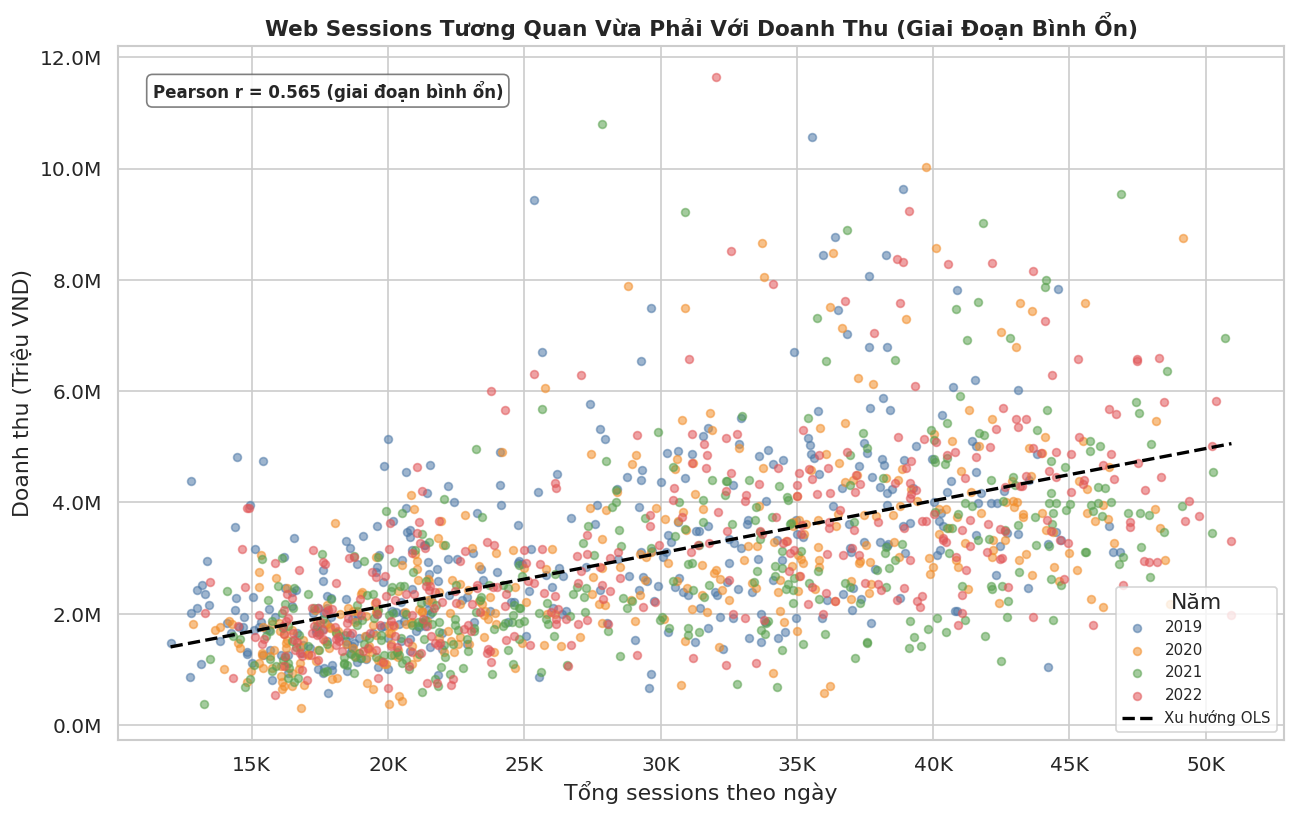

<Figure size 768x576 with 0 Axes>


Pearson r = 0.5651  |  N = 1,461 ngày


In [29]:
# ── 4a: Scatter Web Sessions vs Doanh thu — giai đoạn bình ổn 2019–2022 ─────────────────
from scipy import stats

traffic = pd.read_csv('/content/web_traffic.csv', parse_dates=["date"])
traffic["Year"] = traffic["date"].dt.year

# Tổng sessions theo ngày (gộp tất cả nguồn traffic)
daily_traffic = (
    traffic[traffic["Year"].between(2019, 2022)]
    .groupby("date")["sessions"]
    .sum()
    .reset_index()
    .rename(columns={"date": "Date"})
)

# Ghép với doanh thu
scatter_df = daily_traffic.merge(
    sales[sales["Year"].between(2019, 2022)][["Date", "Revenue", "Year"]],
    on="Date",
    how="inner",
)

# Tính Pearson r
r, _ = stats.pearsonr(scatter_df["sessions"], scatter_df["Revenue"])

# OLS trend line
slope, intercept, *_ = stats.linregress(scatter_df["sessions"], scatter_df["Revenue"])
x_fit = np.linspace(scatter_df["sessions"].min(), scatter_df["sessions"].max(), 200)
y_fit = slope * x_fit + intercept

# Màu theo năm
YEAR_COLORS = {2019: "#4e79a7", 2020: "#f28e2b", 2021: "#59a14f", 2022: "#e15759"}

fig, ax = plt.subplots(figsize=(11, 7))

for yr, grp in scatter_df.groupby("Year"):
    ax.scatter(
        grp["sessions"], grp["Revenue"] / 1e6,
        color=YEAR_COLORS[yr], label=str(yr),
        s=22, alpha=0.55, zorder=3,
    )

ax.plot(x_fit, y_fit / 1e6, color="black", linewidth=2, linestyle="--",
        label="Xu hướng OLS", zorder=4)

# Chú thích Pearson r — góc trên trái
ax.text(
    0.03, 0.95,
    f"Pearson r = {r:.3f} (giai đoạn bình ổn)",
    transform=ax.transAxes,
    fontsize=10, fontweight="bold",
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="dimgray", alpha=0.85),
)

ax.set_xlabel("Tổng sessions theo ngày")
ax.set_ylabel("Doanh thu (Triệu VND)")
ax.set_title(
    "Web Sessions Tương Quan Vừa Phải Với Doanh Thu (Giai Đoạn Bình Ổn)",
    fontsize=13, fontweight="bold",
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}M"))
ax.legend(title="Năm", loc="lower right", fontsize=9)

savefig("v2_4a_web_traffic_scatter.png")

fig.text(
    0.5, -0.04,
    "Dữ liệu traffic kết thúc năm 2022. Cho dự báo 2023–2024,\n"
    "dùng lag features thay vì live traffic.",
    ha="center", fontsize=9, color="dimgray", style="italic",
)
plt.tight_layout()
plt.show()

print(f"\nPearson r = {r:.4f}  |  N = {len(scatter_df):,} ngày")

In [30]:
# ── 4b: Bảng lựa chọn đặc trưng ──────────────────────────────────────────────────────────
feature_data = {
    "Tín hiệu": [
        "Tháng (Fourier sin/cos)",
        "Ngày trong tuần",
        "Cờ ngày lễ Việt Nam",
        "Cờ chế độ (hậu 2018)",
        "Revenue lag 7d/14d/30d",
        "Web sessions lag-1",
        "Tỷ lệ trả hàng",
        "Bounce rate",
        "Tăng trưởng số khách hàng",
    ],
    "Dùng trong mô hình": [
        "Có", "Có", "Có", "Có", "Có",
        "Tùy chọn", "Không", "Không", "Không",
    ],
    "Lý do": [
        "Biên độ T5–T12 gấp 2.9×",
        "Khoảng cách T4–T6 là 15.5%",
        "Lift đã biết +23.7%",
        "Đứt gãy cơ cấu −41.5%",
        "Tự tương quan chuỗi thời gian",
        "r=0.565 trong giai đoạn bình ổn",
        "3.5% số mặt hàng — không đáng kể",
        "r=−0.021 với doanh thu",
        "Tách rời khỏi doanh thu sau 2019",
    ],
    "Nguồn": [
        "sales.csv",
        "sales.csv",
        "engineered",
        "sales.csv",
        "sales.csv",
        "web_traffic.csv",
        "returns.csv",
        "web_traffic.csv",
        "customers.csv",
    ],
}

feat_df = pd.DataFrame(feature_data)

USE_COLORS = {
    "Có":       "#d4edda",   # xanh lá nhạt
    "Tùy chọn": "#fff3cd",   # vàng nhạt
    "Không":    "#f8d7da",   # đỏ nhạt
}

def highlight_use(val):
    bg = USE_COLORS.get(val, "white")
    weight = "bold" if val in ("Có", "Không") else "normal"
    return f"background-color: {bg}; font-weight: {weight}"

styled = (
    feat_df.style
    .applymap(highlight_use, subset=["Dùng trong mô hình"])
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#343a40"), ("color", "white"),
                   ("font-weight", "bold"), ("text-align", "left"),
                   ("padding", "8px 12px")]},
        {"selector": "tbody td",
         "props": [("padding", "7px 12px"), ("border-bottom", "1px solid #dee2e6"),
                   ("text-align", "left")]},
        {"selector": "tbody tr:hover",
         "props": [("background-color", "#f1f3f5")]},
        {"selector": "",
         "props": [("border-collapse", "collapse"), ("width", "100%"),
                   ("font-size", "13px")]},
    ])
    .hide(axis="index")
    .set_caption("<b>Bảng 4b — Lựa chọn đặc trưng mô hình dự báo</b>")
)

display(styled)

Tín hiệu,Dùng trong mô hình,Lý do,Nguồn
Tháng (Fourier sin/cos),Có,Biên độ T5–T12 gấp 2.9×,sales.csv
Ngày trong tuần,Có,Khoảng cách T4–T6 là 15.5%,sales.csv
Cờ ngày lễ Việt Nam,Có,Lift đã biết +23.7%,engineered
Cờ chế độ (hậu 2018),Có,Đứt gãy cơ cấu −41.5%,sales.csv
Revenue lag 7d/14d/30d,Có,Tự tương quan chuỗi thời gian,sales.csv
Web sessions lag-1,Tùy chọn,r=0.565 trong giai đoạn bình ổn,web_traffic.csv
Tỷ lệ trả hàng,Không,3.5% số mặt hàng — không đáng kể,returns.csv
Bounce rate,Không,r=−0.021 với doanh thu,web_traffic.csv
Tăng trưởng số khách hàng,Không,Tách rời khỏi doanh thu sau 2019,customers.csv


### Kết luận Hồi 4: Điểm neo cho mô hình dự báo

**Tối ưu hóa biến đầu vào:**
- **Web Traffic:** Có tương quan thuận (r=0.56) nhưng không thể dùng trực tiếp cho 2023-2024 vì thiếu dữ liệu tương lai. Giải pháp: Sử dụng **Lag Features** của doanh thu để hấp thụ gián tiếp tín hiệu này.
- **Loại bỏ nhiễu:** Các biến như tỷ lệ trả hàng, bounce rate và tăng trưởng khách hàng bị loại do tương quan cực yếu với doanh thu thực tế.

**Chiến lược Model:** Ưu tiên các biến về chu kỳ thời gian và các biến trễ (Lags) để phản ánh chính xác trạng thái bình ổn của doanh nghiệp.